# Orbital-band power in LR04 and CO₂

Estimate obliquity and precession band power over the past 800 kyr using [LR04](https://doi.org/10.1029/2004PA001071) and the [CO₂ composite](https://doi.org/10.1002/2014GL061957).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend, periodogram
from IPython.display import display, Markdown

%matplotlib inline

age_start, age_end = 0.0, 800.0
step_kyr = 1.0
bands_kyr = {"Obliquity": (35.0, 45.0), "Precession": (18.0, 26.0)}
windows = ("boxcar", "hann")  # 主分析：矩形窗；对照：Hann 窗。

input_dir = Path("data/processed/forcings")
output_dir = Path("data/processed/background_orbital_spectra")
figure_dir = Path("figures/background_orbital_spectra")
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

## 1. Data and time grid

Interpolate both native records onto a 1-kyr grid spanning 0–800 kyr BP without extrapolation.

In [2]:
lr04 = pd.read_csv(input_dir / "lr04.csv")
co2 = pd.read_csv(input_dir / "co2.csv")
records = {"LR04": (lr04, "lr04"), "CO2": (co2, "co2_ppm")}

age_grid = np.arange(age_start, age_end + step_kyr / 2, step_kyr)
uniform = pd.DataFrame({"age_kyr_bp": age_grid})
sampling_rows = []
for name, (native, column) in records.items():
    age = native["age_kyr_bp"].to_numpy()
    values = native[column].to_numpy()
    assert np.isfinite(age).all() and np.isfinite(values).all()
    assert (np.diff(age) > 0).all()
    assert age[0] <= age_grid[0] and age[-1] >= age_grid[-1]
    uniform[name] = np.interp(age_grid, age, values)
    selected_age = age[(age >= age_start) & (age <= age_end)]
    gaps = np.diff(selected_age)
    sampling_rows.append({"record": name, "native_points_0_800": len(selected_age),
                          "median_gap_kyr": np.median(gaps), "max_gap_kyr": gaps.max()})

sampling = pd.DataFrame(sampling_rows).set_index("record")
display(sampling.round(3))
print(f"Uniform grid: {age_grid[0]:g}–{age_grid[-1]:g} kyr BP; "
      f"{len(age_grid)} points, step = {step_kyr:g} kyr")

,native_points_0_800,median_gap_kyr,max_gap_kyr
record,,,
LR04,701,1.000,2.000
CO2,1832,0.306,4.171


Uniform grid: 0–800 kyr BP; 801 points, step = 1 kyr


## 2. Spectral power

Calculate 35–45-kyr obliquity and 18–26-kyr precession power as fractions of all positive-frequency power after linear detrending, using boxcar spectra to partition variance and Hann spectra to check window sensitivity.

In [3]:
spectra = {}
power_rows = []
for name in records:
    anomaly = detrend(uniform[name].to_numpy(), type="linear")
    for window in windows:
        frequency, psd = periodogram(anomaly, fs=1 / step_kyr, window=window,
                                     detrend=False, scaling="density")
        df = frequency[1] - frequency[0]
        positive = frequency > 0
        total_power = psd[positive].sum() * df
        if window == "boxcar":
            np.testing.assert_allclose(total_power, np.var(anomaly), rtol=1e-12)
        spectra[name, window] = pd.DataFrame({
            "frequency_per_kyr": frequency[positive], "psd": psd[positive],
            "normalized_psd": psd[positive] / total_power})
        for band, (short_period, long_period) in bands_kyr.items():
            inside = (frequency >= 1 / long_period) & (frequency <= 1 / short_period)
            band_power = psd[inside].sum() * df
            power_rows.append({"record": name, "window": window, "band": band,
                               "period_min_kyr": short_period, "period_max_kyr": long_period,
                               "band_power": band_power, "total_power": total_power,
                               "weight_pct": 100 * band_power / total_power})

band_power = pd.DataFrame(power_rows)
weights = band_power.pivot(index=["record", "window"], columns="band", values="weight_pct")
weights = weights.reindex(pd.MultiIndex.from_product([["LR04", "CO2"], windows],
                                                    names=["record", "window"]))
display(weights.round(2))
print(f"Frequency spacing = {df:.6f} cycles/kyr; Nyquist = {1 / (2 * step_kyr):.3f} cycles/kyr")

band           Obliquity  Precession
record window                       
LR04   boxcar      17.27        7.90
       hann        14.76        4.46
CO2    boxcar       7.26        5.52
       hann         3.48        4.11

Frequency spacing = 0.001248 cycles/kyr; Nyquist = 0.500 cycles/kyr


## 3. Records and spectra

Compare native and interpolated records alongside normalized spectra, with shading marking the orbital bands.

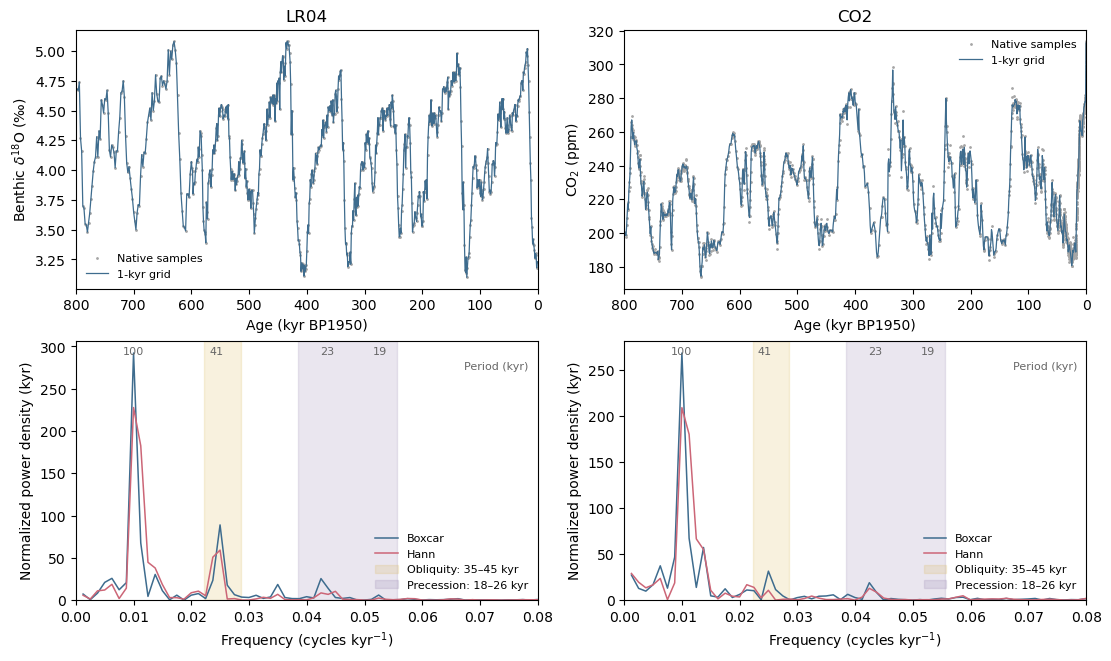

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
colors = {"boxcar": "#3E6C8E", "hann": "#CC6677"}
units = {"LR04": r"Benthic $\delta^{18}$O (‰)", "CO2": r"CO$_2$ (ppm)"}
for column_index, (name, (native, column)) in enumerate(records.items()):
    ax = axes[0, column_index]
    selected = native["age_kyr_bp"].between(age_start, age_end)
    ax.plot(native.loc[selected, "age_kyr_bp"], native.loc[selected, column],
            ".", ms=2, color="0.65", label="Native samples")
    ax.plot(age_grid, uniform[name], lw=0.9, color=colors["boxcar"], label="1-kyr grid")
    ax.set(xlim=(age_end, age_start), xlabel="Age (kyr BP1950)", ylabel=units[name], title=name)
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, column_index]
    for window in windows:
        spectrum = spectra[name, window]
        ax.plot(spectrum["frequency_per_kyr"], spectrum["normalized_psd"],
                lw=1.1, color=colors[window], label=window.capitalize())
    for (band, (short_period, long_period)), color in zip(bands_kyr.items(), ["#D9B44A", "#8B78A9"]):
        ax.axvspan(1 / long_period, 1 / short_period, color=color, alpha=0.18,
                   label=f"{band}: {short_period:g}–{long_period:g} kyr")
    ax.set(xlim=(0, 0.08), ylim=(0, None), xlabel=r"Frequency (cycles kyr$^{-1}$)",
           ylabel="Normalized power density (kyr)")
    ax.legend(frameon=False, fontsize=8)
    for period in (100, 41, 23, 19):
        ax.text(1 / period, 0.98, f"{period}", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=8, color="0.4")
    ax.text(0.98, 0.89, "Period (kyr)", transform=ax.transAxes, ha="right", fontsize=8, color="0.4")

fig.savefig(figure_dir / "background_orbital_spectra.png", dpi=180)
plt.show()

In [5]:
band_power.to_csv(output_dir / "band_power.csv", index=False)
uniform.to_csv(output_dir / "uniform_series.csv", index=False)
spectra_table = pd.concat([table.assign(record=name, window=window)
                          for (name, window), table in spectra.items()], ignore_index=True)
spectra_table.to_csv(output_dir / "spectra.csv", index=False)

primary = weights.xs("boxcar", level="window")
display(Markdown(
    "## Band-power summary\n\n"
    f"With boxcar spectra and linear detrending, obliquity accounts for "
    f"**{primary.loc['LR04', 'Obliquity']:.2f}%** of LR04 variance and "
    f"**{primary.loc['CO2', 'Obliquity']:.2f}%** of CO₂ variance, "
    f"while precession accounts for **{primary.loc['LR04', 'Precession']:.2f}%** "
    f"and **{primary.loc['CO2', 'Precession']:.2f}%**, respectively."))


## Band-power summary

With boxcar spectra and linear detrending, obliquity accounts for **17.27%** of LR04 variance and **7.26%** of CO₂ variance, while precession accounts for **7.90%** and **5.52%**, respectively.

## Interpretation

Shared periods do not establish causality or regression overlap, particularly given [LR04’s orbital tuning](https://lorraine-lisiecki.com/stack.html) and the longer analysis interval.